In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = Path.cwd().parent

MODEL_FILE = BASE_DIR / "models" / "aqi_model.pkl"
FEATURE_SCHEMA_FILE = BASE_DIR / "models" / "feature_columns.pkl"
DATA_FILE = BASE_DIR / "data" / "processed" / "AQI_feature_engineered.csv"
REPORTS_DIR = BASE_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", BASE_DIR)

Project root: c:\Users\chanchal_soni\Desktop\10_pearlsshine_internship\1st_project\pearls-aqi-predictor


In [4]:
model = joblib.load(MODEL_FILE)
feature_columns = joblib.load(FEATURE_SCHEMA_FILE)
df = pd.read_csv(DATA_FILE)

print("Model:", type(model).__name__)
print("Feature count:", len(feature_columns))
print("Dataset shape:", df.shape)

Model: RandomForestRegressor
Feature count: 16
Dataset shape: (123, 17)


In [5]:
X = df[feature_columns].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

X = X.astype(float)

print("SHAP input shape:", X.shape)
print("Features:", list(X.columns))

SHAP input shape: (122, 16)
Features: ['CO', 'NO', 'NO2', 'O3', 'SO2', 'PM2_5', 'PM10', 'NH3', 'hour', 'day', 'month', 'weekday', 'AQI', 'AQI_lag_1', 'AQI_change', 'AQI_rolling_avg']


In [6]:
sample_size = min(100, len(X))
X_sample = X.tail(sample_size).copy()

print("Samples used for SHAP:", len(X_sample))

Samples used for SHAP: 100


In [7]:
explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)

print("SHAP explanation generated successfully.")

SHAP explanation generated successfully.


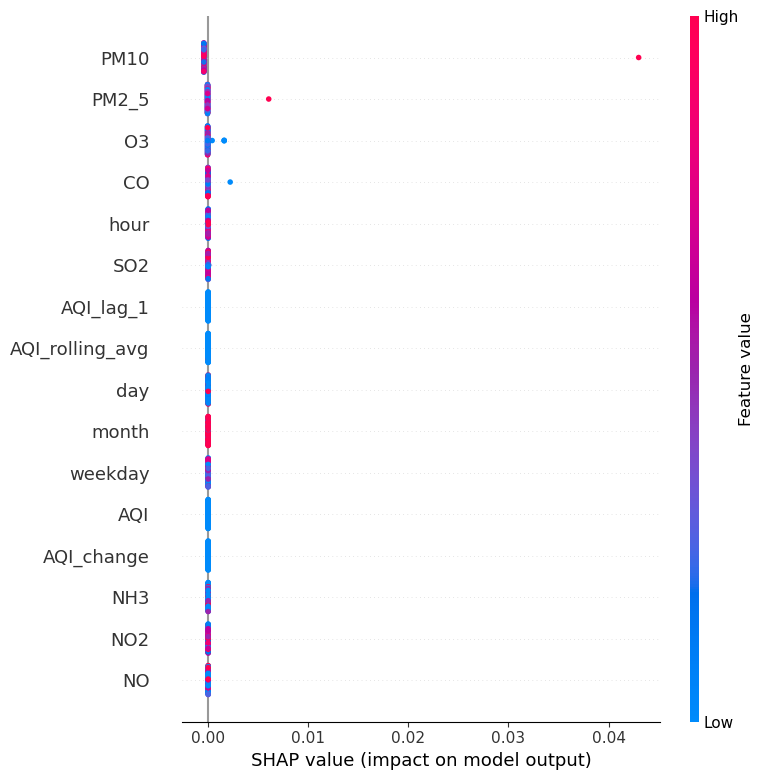

In [8]:
shap.summary_plot(
    shap_values,
    X_sample,
    show=True
)

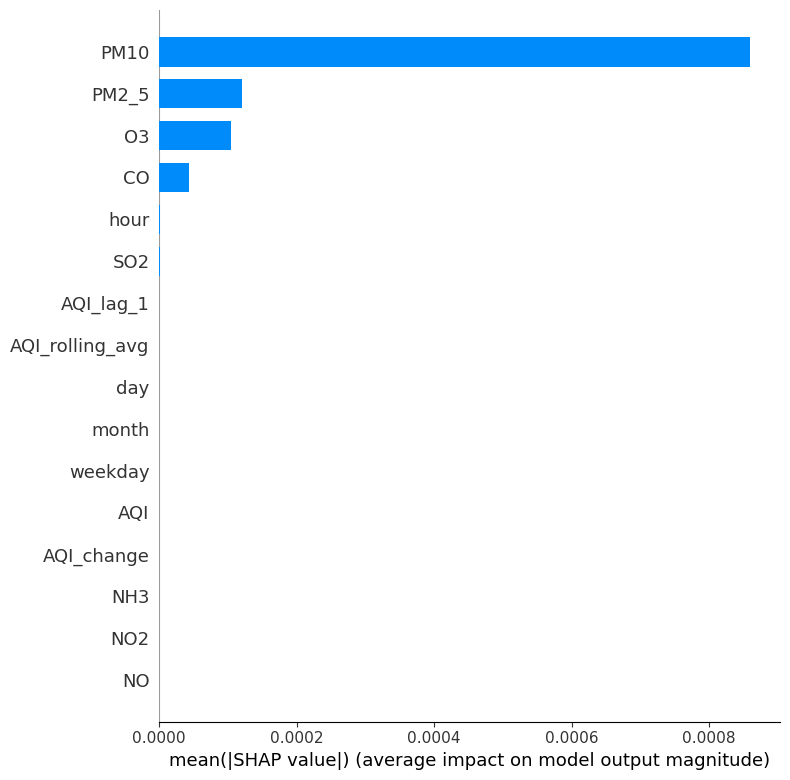

In [9]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=True
)

In [10]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_absolute_shap": mean_abs_shap
}).sort_values(
    "mean_absolute_shap",
    ascending=False
).reset_index(drop=True)

importance_file = REPORTS_DIR / "shap_feature_importance.csv"

importance_df.to_csv(importance_file, index=False)

print("SHAP feature importance saved to:")
print(importance_file)

print("\nTop 10 important features:")
print(importance_df.head(10).to_string(index=False))

SHAP feature importance saved to:
c:\Users\chanchal_soni\Desktop\10_pearlsshine_internship\1st_project\pearls-aqi-predictor\reports\shap_feature_importance.csv

Top 10 important features:
feature  mean_absolute_shap
   PM10            0.000860
  PM2_5            0.000121
     O3            0.000104
     CO            0.000044
   hour            0.000001
    SO2            0.000001
    NO2            0.000000
     NO            0.000000
    NH3            0.000000
    day            0.000000


In [11]:
assert len(importance_df) == len(feature_columns)
assert importance_df["mean_absolute_shap"].notna().all()

print("\nSHAP validation passed.")
print("Explainability analysis completed successfully.")


SHAP validation passed.
Explainability analysis completed successfully.
